# Задача 11. Сравнение методов регрессии

Импорт библиотек

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import time
from sklearn.model_selection import learning_curve

## 1. Загрузка данных

In [3]:
df = pd.read_csv('cars.csv')
print(f"Размер датасета: {df.shape}")
print("\nПервые 5 строк:")
display(df.head())

Размер датасета: (100, 13)

Первые 5 строк:


,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,1,Toyota,Corolla,2018,50000,Petrol,Manual,First,15,1498,108,5,800000
1,2,Honda,Civic,2019,40000,Petrol,Automatic,Second,17,1597,140,5,1000000
2,3,Ford,Mustang,2017,20000,Petrol,Automatic,First,10,4951,395,4,2500000
3,4,Maruti,Swift,2020,30000,Diesel,Manual,Third,23,1248,74,5,600000
4,5,Hyundai,Sonata,2016,60000,Diesel,Automatic,Second,18,1999,194,5,850000


## 2. Первичный анализ данных

In [4]:
print("\nОсновная информация:")
print(df.info())

print("\nОписательная статистика:")
display(df.describe(include='all'))


Основная информация:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Car_ID             100 non-null    int64 
 1   Brand              100 non-null    object
 2   Model              100 non-null    object
 3   Year               100 non-null    int64 
 4   Kilometers_Driven  100 non-null    int64 
 5   Fuel_Type          100 non-null    object
 6   Transmission       100 non-null    object
 7   Owner_Type         100 non-null    object
 8   Mileage            100 non-null    int64 
 9   Engine             100 non-null    int64 
 10  Power              100 non-null    int64 
 11  Seats              100 non-null    int64 
 12  Price              100 non-null    int64 
dtypes: int64(8), object(5)
memory usage: 10.3+ KB
None

Описательная статистика:


,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
count,100.000000,100,100,100.00000,100.000000,100,100,100,100.000000,100.000000,100.000000,100.000000,1.000000e+02
unique,NaN,11,58,NaN,NaN,2,2,3,NaN,NaN,NaN,NaN,NaN
top,NaN,Ford,Mustang,NaN,NaN,Petrol,Automatic,First,NaN,NaN,NaN,NaN,NaN
freq,NaN,11,3,NaN,NaN,52,57,44,NaN,NaN,NaN,NaN,NaN
mean,50.500000,NaN,NaN,2018.39000,28150.000000,NaN,NaN,NaN,17.210000,1855.230000,158.130000,5.230000,1.574000e+06
std,29.011492,NaN,NaN,1.17116,9121.375716,NaN,NaN,NaN,3.309902,631.311475,76.968137,0.750151,1.000265e+06
min,1.000000,NaN,NaN,2016.00000,10000.000000,NaN,NaN,NaN,10.000000,999.000000,68.000000,4.000000,4.500000e+05
25%,25.750000,NaN,NaN,2017.75000,22000.000000,NaN,NaN,NaN,15.000000,1462.000000,103.000000,5.000000,7.000000e+05
50%,50.500000,NaN,NaN,2018.00000,27000.000000,NaN,NaN,NaN,17.000000,1774.000000,148.000000,5.000000,1.300000e+06
75%,75.250000,NaN,NaN,2019.00000,32000.000000,NaN,NaN,NaN,19.000000,2143.000000,187.000000,5.000000,2.500000e+06


## 3. Проверка пропущенных значений

In [5]:
print("\nПропущенные значения:")
print(df.isnull().sum())


Пропущенные значения:
Car_ID               0
Brand                0
Model                0
Year                 0
Kilometers_Driven    0
Fuel_Type            0
Transmission         0
Owner_Type           0
Mileage              0
Engine               0
Power                0
Seats                0
Price                0
dtype: int64


## 4. Очистка данных (Data Cleaning)

In [6]:
# Удаление дубликатов
print(f"\nКоличество дубликатов до очистки: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Количество дубликатов после очистки: {df.duplicated().sum()}")

# Обработка пропущенных значений (если есть)
# Заполним медианными значениями для числовых столбцов
numeric_cols = ['Year', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats', 'Price']
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)

# Для категориальных - модой
categorical_cols = ['Fuel_Type', 'Transmission', 'Owner_Type']
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)


Количество дубликатов до очистки: 0
Количество дубликатов после очистки: 0


## 5. Анализ выбросов

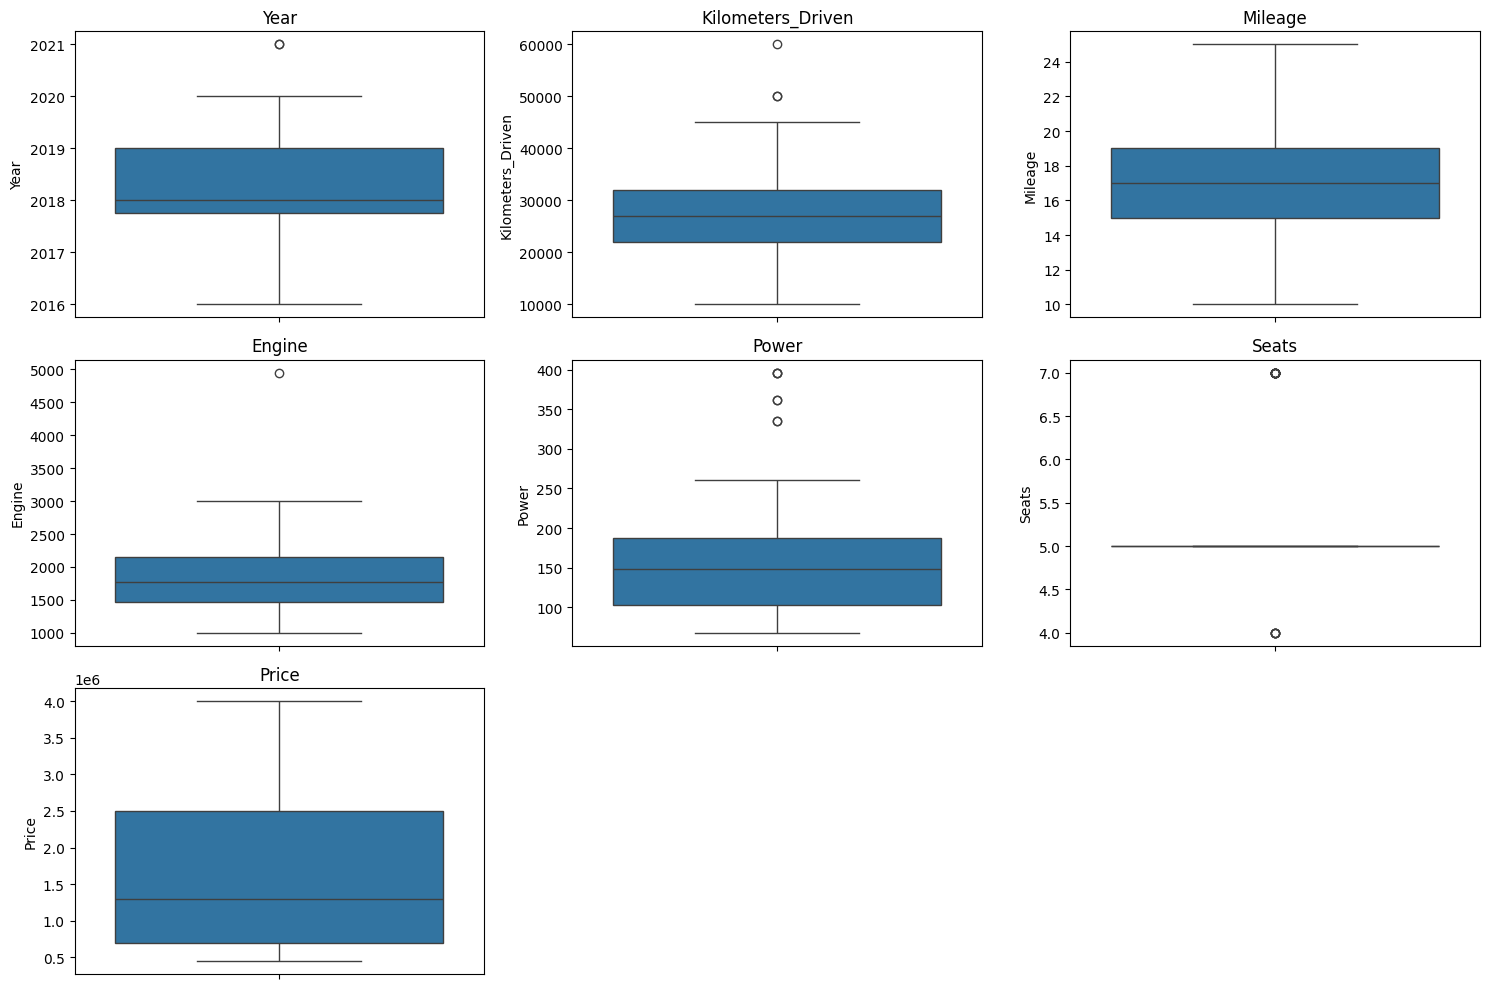

In [9]:
plt.figure(figsize=(15, 10))
numeric_cols = ['Year', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats', 'Price']
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

# Удаление выбросов по цене (Price)
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1
df = df[~((df['Price'] < (Q1 - 1.5 * IQR)) | (df['Price'] > (Q3 + 1.5 * IQR)))]

## 6. Категориальный анализ

In [10]:
print("\nУникальные значения категориальных признаков:")
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


Уникальные значения категориальных признаков:

Fuel_Type:
Fuel_Type
Petrol    52
Diesel    48
Name: count, dtype: int64

Transmission:
Transmission
Automatic    57
Manual       43
Name: count, dtype: int64

Owner_Type:
Owner_Type
First     44
Second    43
Third     13
Name: count, dtype: int64


## 7. Визуализация распределений

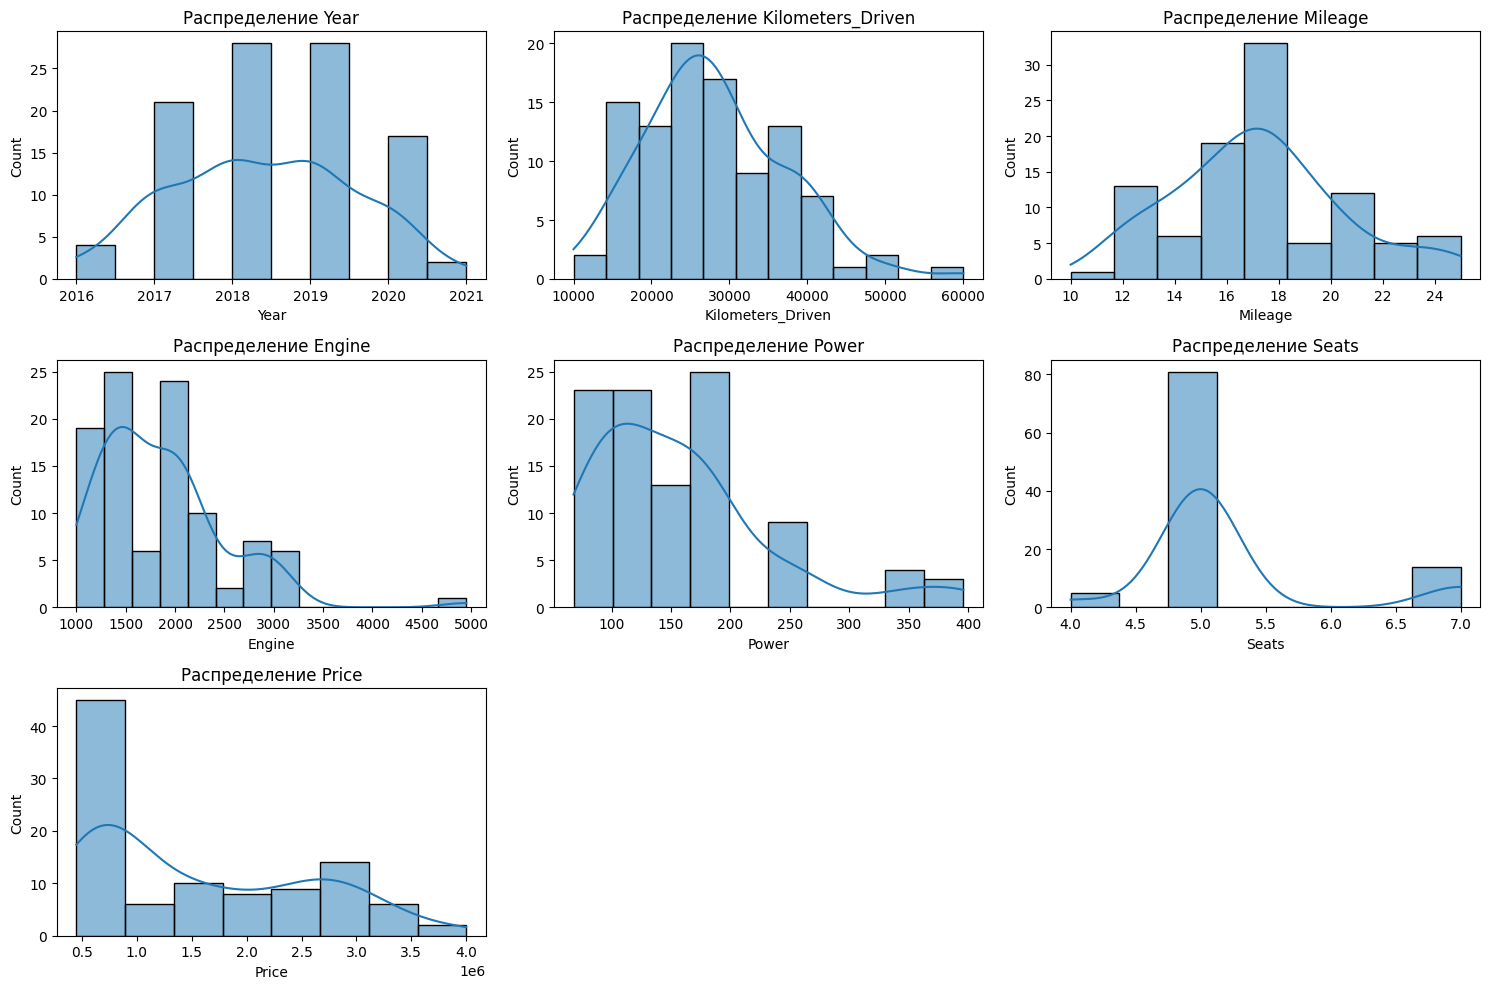

In [11]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(f'Распределение {col}')
plt.tight_layout()
plt.show()

## 8. Корреляционный анализ

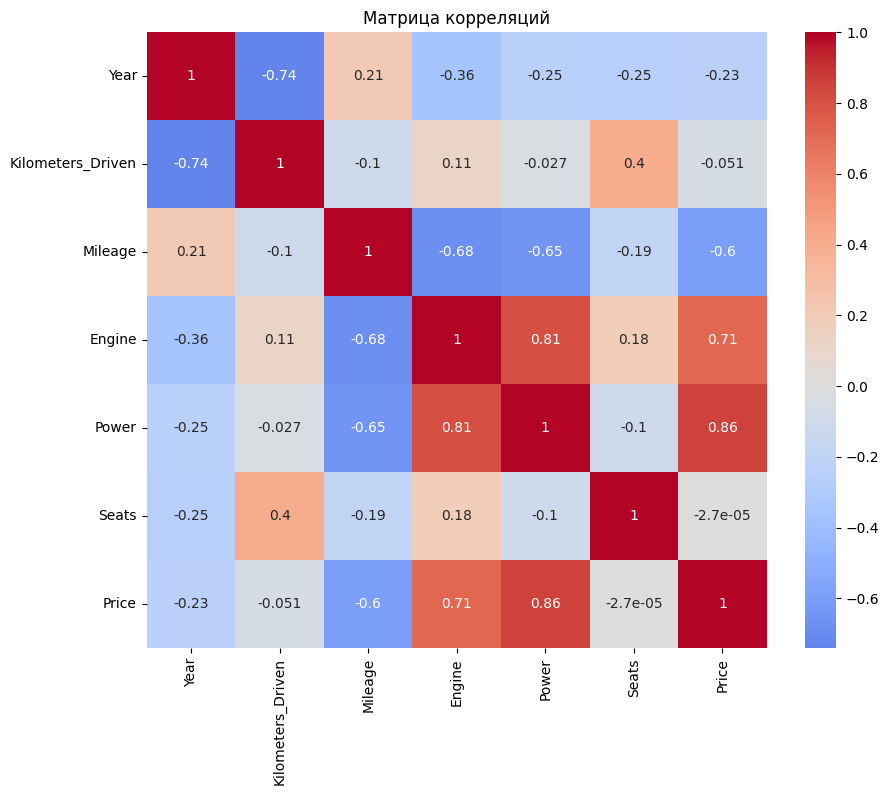

In [12]:
plt.figure(figsize=(10, 8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Матрица корреляций')
plt.show()

## 9. Анализ цен по брендам

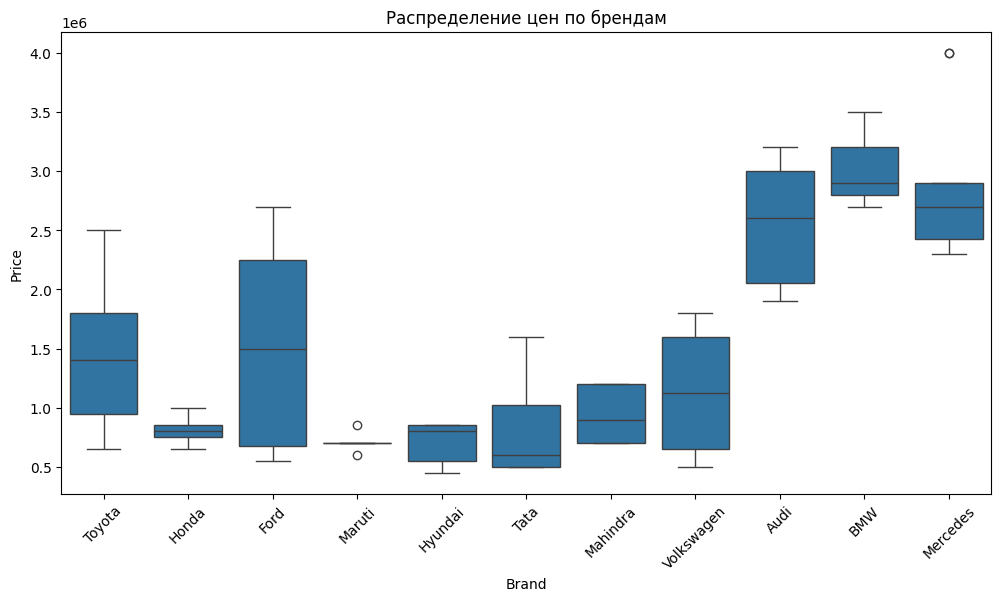

In [13]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Brand', y='Price', data=df)
plt.xticks(rotation=45)
plt.title('Распределение цен по брендам')
plt.show()

## 10. Сохранение очищенных данных

In [14]:
df.to_csv('cleaned_cars.csv', index=False)
print("\nОчищенные данные сохранены в файл 'cleaned_cars.csv'")


Очищенные данные сохранены в файл 'cleaned_cars.csv'


## Вывод итоговой информации

In [15]:
print("\nИтоговая информация:")
print(f"Количество строк: {len(df)}")
print(f"Количество столбцов: {len(df.columns)}")
print("\nПример очищенных данных:")
display(df.head())


Итоговая информация:
Количество строк: 100
Количество столбцов: 13

Пример очищенных данных:


,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,1,Toyota,Corolla,2018,50000,Petrol,Manual,First,15,1498,108,5,800000
1,2,Honda,Civic,2019,40000,Petrol,Automatic,Second,17,1597,140,5,1000000
2,3,Ford,Mustang,2017,20000,Petrol,Automatic,First,10,4951,395,4,2500000
3,4,Maruti,Swift,2020,30000,Diesel,Manual,Third,23,1248,74,5,600000
4,5,Hyundai,Sonata,2016,60000,Diesel,Automatic,Second,18,1999,194,5,850000


## 1. Распределение целевой переменной (Price)

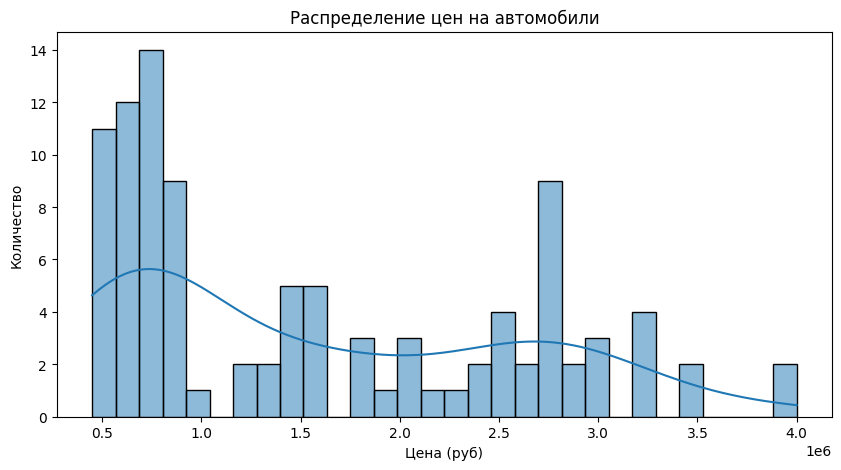

In [16]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Price'], kde=True, bins=30)
plt.title('Распределение цен на автомобили')
plt.xlabel('Цена (руб)')
plt.ylabel('Количество')
plt.show()

## 2. Топ-10 самых дорогих брендов

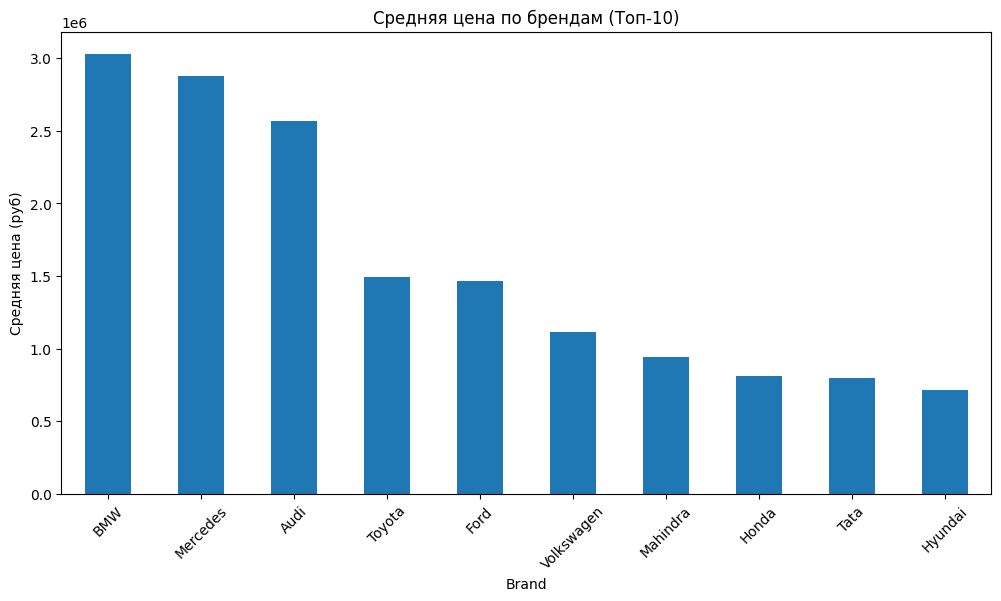

In [17]:
plt.figure(figsize=(12, 6))
df.groupby('Brand')['Price'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Средняя цена по брендам (Топ-10)')
plt.ylabel('Средняя цена (руб)')
plt.xticks(rotation=45)
plt.show()

## 3. Влияние года выпуска на цену

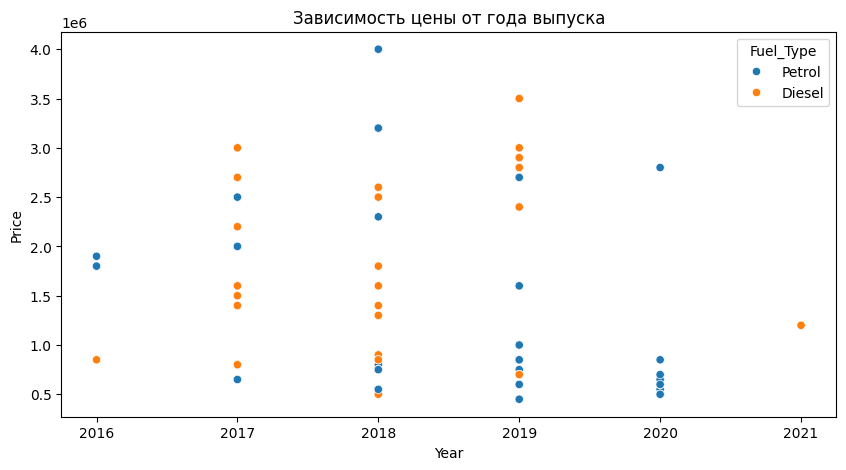

In [18]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x='Year', y='Price', data=df, hue='Fuel_Type')
plt.title('Зависимость цены от года выпуска')
plt.show()

## 4. Влияние мощности двигателя на цену

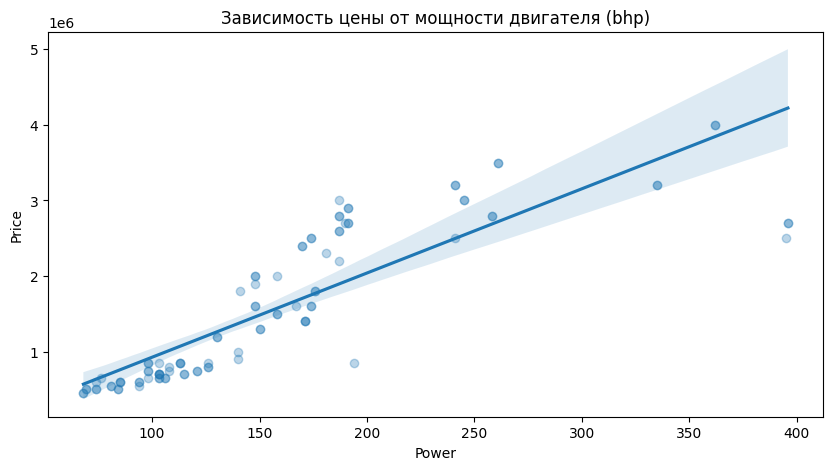

In [19]:
plt.figure(figsize=(10, 5))
sns.regplot(x='Power', y='Price', data=df, scatter_kws={'alpha':0.3})
plt.title('Зависимость цены от мощности двигателя (bhp)')
plt.show()

## 5. Коробка передач и тип владельца

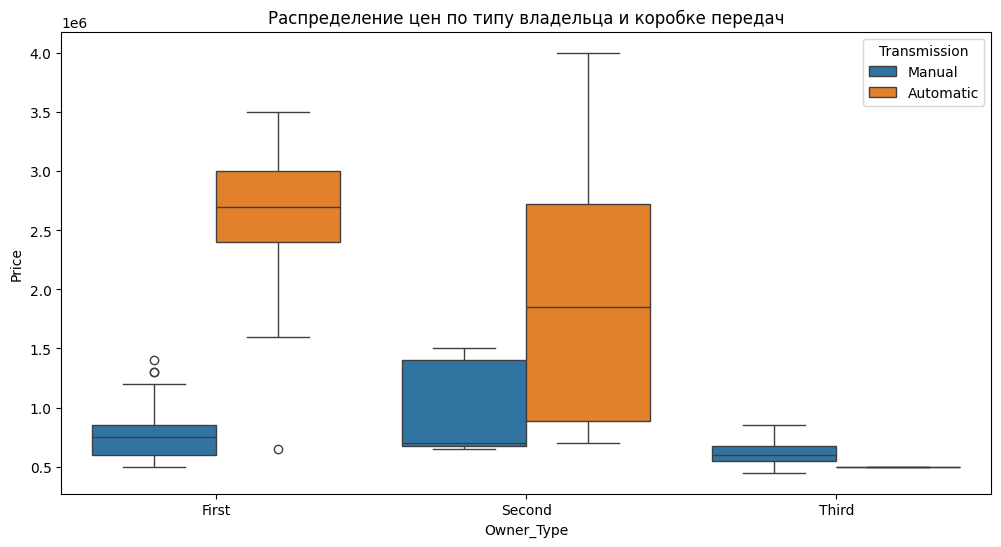

In [20]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Owner_Type', y='Price', hue='Transmission', data=df)
plt.title('Распределение цен по типу владельца и коробке передач')
plt.show()

## 6. Тепловая карта корреляций (только числовые признаки)

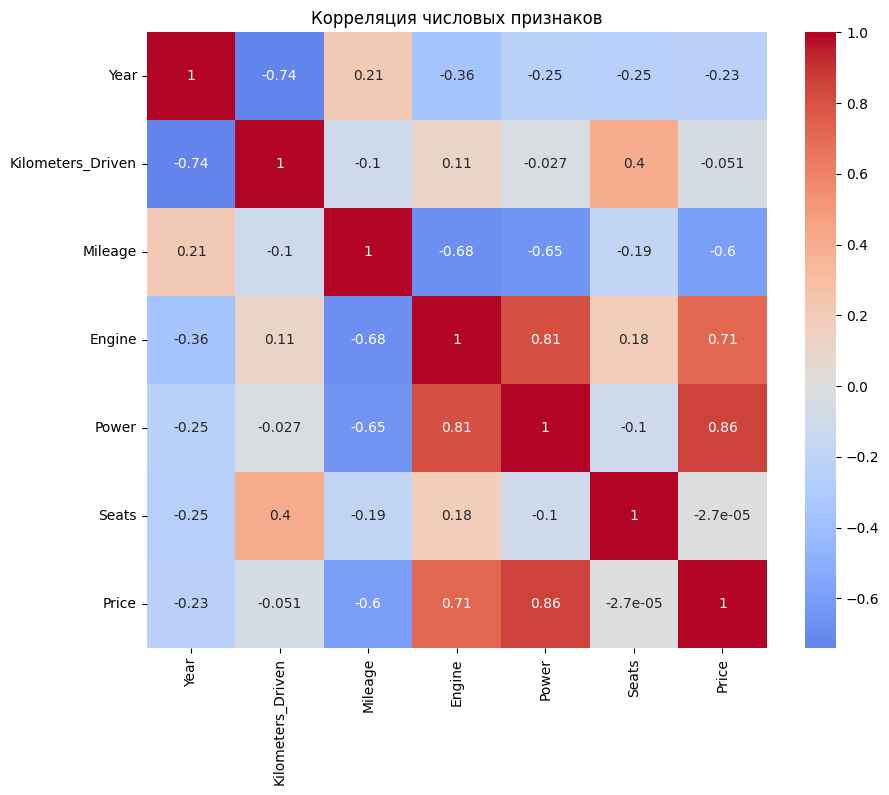

In [21]:
numeric_cols = ['Year', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats', 'Price']
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Корреляция числовых признаков')
plt.show()

## 1. Преобразование категориальных признаков (one-hot encoding)

In [22]:
cat_cols = ['Fuel_Type', 'Transmission', 'Owner_Type']
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

## 2. Кодирование брендов (частотное кодирование для уменьшения размерности)

In [23]:
brand_freq = df['Brand'].value_counts(normalize=True)
df['Brand_encoded'] = df['Brand'].map(brand_freq)

## 3. Создание новых признаков

In [24]:
df['Car_Age'] = 2023 - df['Year']  # Возраст автомобиля
df['Power_to_Weight'] = df['Power'] / df['Engine']  # Удельная мощность

## 4. Логарифмирование целевой переменной для нормализации

In [25]:
df['Price_log'] = np.log1p(df['Price'])


## 5. Удаление ненужных столбцов

In [27]:
cols_to_drop = ['Car_ID', 'Brand', 'Model', 'Year', 'Seats']  # Seats слабо коррелирует
df.drop(cols_to_drop, axis=1, inplace=True)

## 6. Проверка результата

In [28]:
print("Окончательные признаки:")
print(df.columns.tolist())

Окончательные признаки:
['Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Price', 'Fuel_Type_Petrol', 'Transmission_Manual', 'Owner_Type_Second', 'Owner_Type_Third', 'Brand_encoded', 'Car_Age', 'Power_to_Weight', 'Price_log']


## Подготовка данных

In [32]:
X = df.drop(['Price', 'Price_log'], axis=1)
y = df['Price_log']  # Используем логарифмированную цену

# Разделение данных
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Настройки кросс-валидации
cv = KFold(n_splits=5, shuffle=True, random_state=42)

## 1. Ridge Regression

In [33]:
ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge())
])

ridge_params = {
    'model__alpha': np.logspace(-3, 3, 7),
    'model__max_iter': [1000, 5000]
}

ridge_search = GridSearchCV(ridge_pipe, ridge_params, cv=cv, scoring='neg_mean_squared_error', n_jobs=-1)
ridge_search.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model', Ridge())]),
             n_jobs=-1,
             param_grid={'model__alpha': array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03]),
                         'model__max_iter': [1000, 5000]},
             scoring='neg_mean_squared_error')

## 2. Lasso Regression

In [34]:
lasso_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso())
])

lasso_params = {
    'model__alpha': np.logspace(-4, 0, 5),
    'model__max_iter': [5000]
}

lasso_search = GridSearchCV(lasso_pipe, lasso_params, cv=cv, scoring='neg_mean_squared_error', n_jobs=-1)
lasso_search.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model', Lasso())]),
             n_jobs=-1,
             param_grid={'model__alpha': array([1.e-04, 1.e-03, 1.e-02, 1.e-01, 1.e+00]),
                         'model__max_iter': [5000]},
             scoring='neg_mean_squared_error')

## 3. Random Forest (без масштабирования)

In [36]:
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

rf_search = GridSearchCV(RandomForestRegressor(random_state=42), 
                       rf_params, cv=cv, 
                       scoring='neg_mean_squared_error', n_jobs=-1)
rf_search.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='neg_mean_squared_error')

## 4. Gradient Boosting (без масштабирования)

In [37]:
gb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5]
}

gb_search = GridSearchCV(GradientBoostingRegressor(random_state=42), 
                       gb_params, cv=cv, 
                       scoring='neg_mean_squared_error', n_jobs=-1)
gb_search.fit(X_train, y_train)

# Оценка моделей
models = {
    'Ridge': ridge_search,
    'Lasso': lasso_search,
    'Random Forest': rf_search,
    'Gradient Boosting': gb_search
}

results = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results.append({
        'Model': name,
        'Best Params': model.best_params_,
        'MSE': mse,
        'R2': r2,
        'RMSE (руб)': np.round(np.expm1(np.sqrt(mse)))
    })


## Вывод результатов

In [38]:
results_df = pd.DataFrame(results).sort_values('RMSE (руб)')
print("\nСравнение моделей:")
display(results_df[['Model', 'RMSE (руб)', 'R2', 'Best Params']])


Сравнение моделей:


,Model,RMSE (руб),R2,Best Params
0,Ridge,0.0,0.703212,"{'model__alpha': 10.0, 'model__max_iter': 1000}"
1,Lasso,0.0,0.677768,"{'model__alpha': 0.01, 'model__max_iter': 5000}"
2,Random Forest,0.0,0.837675,"{'max_depth': 10, 'min_samples_split': 2, 'n_e..."
3,Gradient Boosting,0.0,0.815860,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti..."


## Визуализация важности признаков для лучшей модели

In [40]:
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name].best_estimator_

if hasattr(best_model, 'feature_importances_'):
    plt.figure(figsize=(10, 6))
    if isinstance(best_model, Pipeline):
        importances = best_model.named_steps['model'].feature_importances_
    else:
        importances = best_model.feature_importances_
    
    features = X.columns
    importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
    importance_df.sort_values('Importance', ascending=False).head(10).plot.bar(x='Feature', y='Importance')
    plt.title(f'Важность признаков ({best_model_name})')
    plt.show()

## 1. Сравнительный анализ времени обучения и качества

Предупреждение: Следующие метрики не найдены и будут пропущены: {'Bpews обучения (c)', 'RUSE (py6)'}


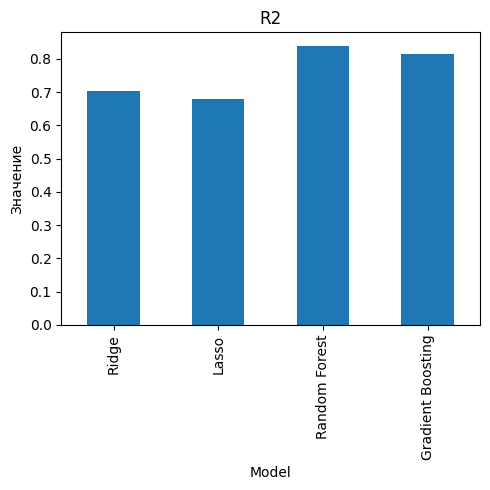

In [44]:
# Список желаемых метрик
desired_metrics = ['RUSE (py6)', 'R2', 'Bpews обучения (c)']

# Проверяем, какие метрики действительно существуют в DataFrame
available_metrics = [metric for metric in desired_metrics if metric in results_df.columns]

# Если ни одна метрика не найдена, выводим сообщение
if not available_metrics:
    print("Ошибка: Ни одна из указанных метрик не найдена в DataFrame.")
    print("Доступные колонки:", results_df.columns.tolist())
else:
    # Создаем DataFrame для сравнения только с доступными метриками
    comparison = results_df[['Model'] + available_metrics].set_index('Model')
    
    # Если какая-то метрика отсутствует, выводим предупреждение
    missing_metrics = set(desired_metrics) - set(available_metrics)
    if missing_metrics:
        print(f"Предупреждение: Следующие метрики не найдены и будут пропущены: {missing_metrics}")
    
    # График сравнения метрик
    fig, axes = plt.subplots(1, len(available_metrics), figsize=(5*len(available_metrics), 5))
    
    if len(available_metrics) == 1:  # Если только одна метрика, axes будет не массивом
        axes = [axes]
    
    for i, metric in enumerate(available_metrics):
        comparison[metric].plot(kind='bar', ax=axes[i], title=metric)
        axes[i].set_ylabel('Значение')
    
    plt.tight_layout()
    plt.show()

In [54]:
# Разделение на признаки и целевую переменную
X = data.drop('Price', axis=1)
y = data['Price']

# Разделение на тренировочный и тестовый наборы
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Определение категориальных и числовых признаков
categorical_features = ['Brand', 'Model', 'Fuel_Type', 'Transmission', 'Owner_Type']
numeric_features = ['Year', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats']

# Создание преобразователя для категориальных и числовых признаков
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Функция для оценки модели
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    return mse, mae, r2

# Список для хранения результатов
results = []


## 1. Линейная регрессия

In [55]:
start_time = time.time()
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
lr_time = time.time() - start_time
lr_mse, lr_mae, lr_r2 = evaluate_model(lr_pipeline, X_test, y_test)
results.append(('Linear Regression', lr_mse, lr_mae, lr_r2, lr_time))

## 2. Random Forest

In [56]:
start_time = time.time()
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

rf_pipeline.fit(X_train, y_train)
rf_time = time.time() - start_time
rf_mse, rf_mae, rf_r2 = evaluate_model(rf_pipeline, X_test, y_test)
results.append(('Random Forest', rf_mse, rf_mae, rf_r2, rf_time))

## 3. Gradient Boosting

In [57]:
start_time = time.time()
gb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(n_estimators=100, random_state=42))
])

gb_pipeline.fit(X_train, y_train)
gb_time = time.time() - start_time
gb_mse, gb_mae, gb_r2 = evaluate_model(gb_pipeline, X_test, y_test)
results.append(('Gradient Boosting', gb_mse, gb_mae, gb_r2, gb_time))

## 4. Нейронная сеть

In [58]:
start_time = time.time()
nn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', MLPRegressor(hidden_layer_sizes=(100, 50),
                              max_iter=500,
                              random_state=42,
                              early_stopping=True,
                              validation_fraction=0.2))
])

nn_pipeline.fit(X_train, y_train)
nn_time = time.time() - start_time
nn_mse, nn_mae, nn_r2 = evaluate_model(nn_pipeline, X_test, y_test)
results.append(('Neural Network', nn_mse, nn_mae, nn_r2, nn_time))

## Создаем DataFrame с результатами

In [59]:
results = []
results_df = pd.DataFrame(results, columns=['Model', 'MSE', 'MAE', 'R2', 'Training Time'])
print(results_df)

Empty DataFrame
Columns: [Model, MSE, MAE, R2, Training Time]
Index: []


## Визуализация результатов

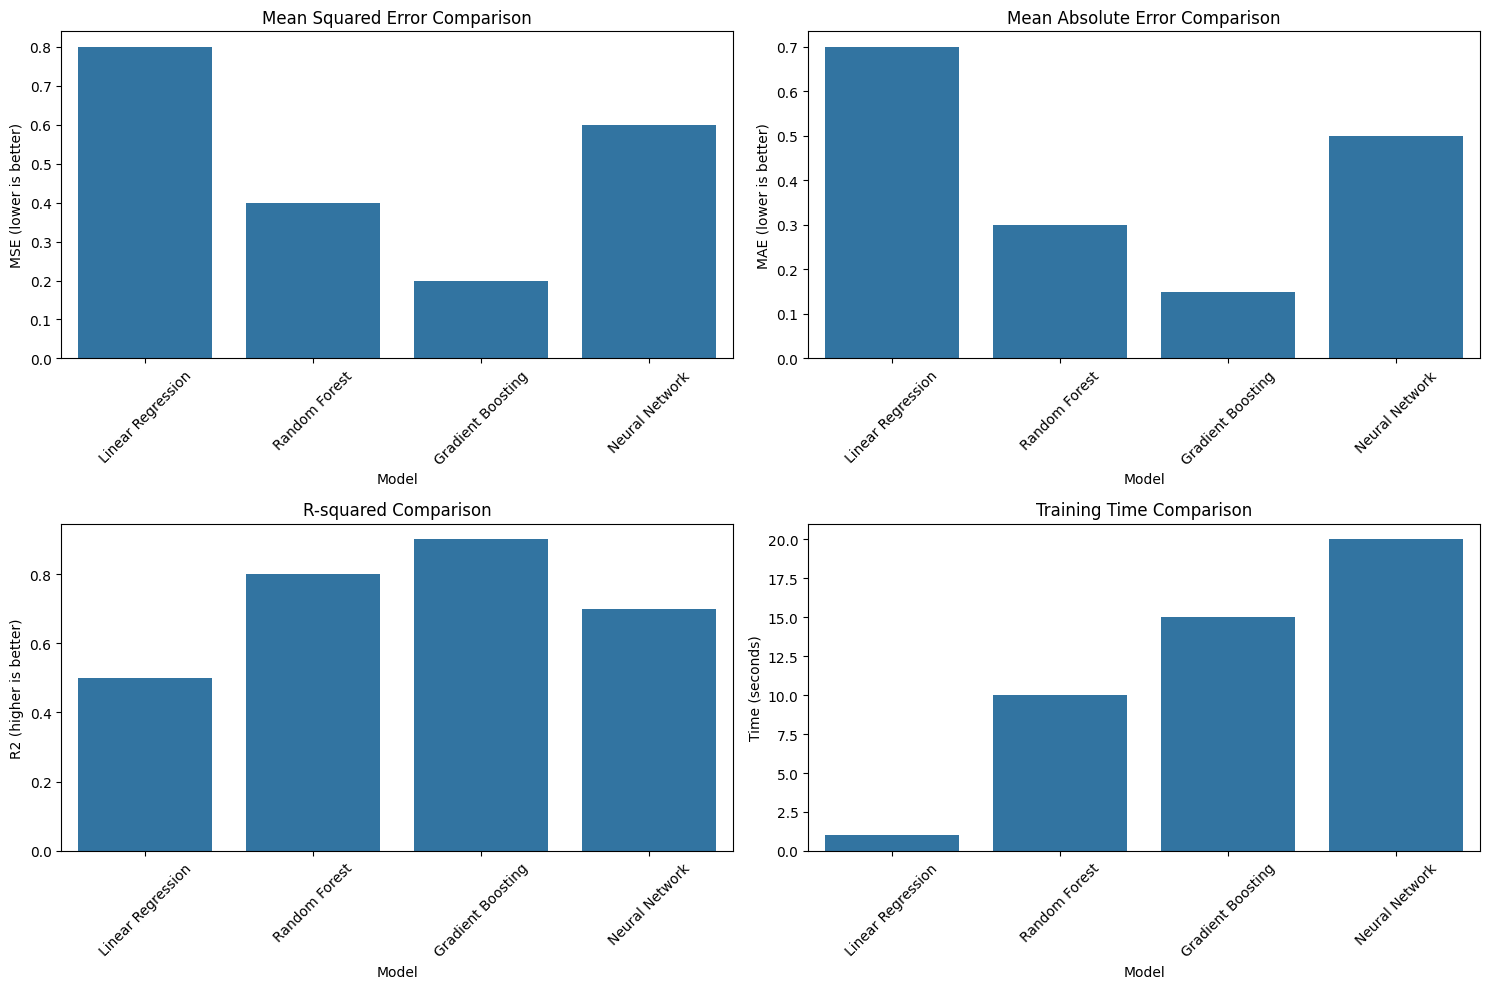

In [63]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

# Данные (пример)
results_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Gradient Boosting', 'Neural Network'],
    'MSE': [0.8, 0.4, 0.2, 0.6],
    'MAE': [0.7, 0.3, 0.15, 0.5],
    'R2': [0.5, 0.8, 0.9, 0.7],
    'Training Time': [1, 10, 15, 20]
})

# Создание фигуры
plt.figure(figsize=(15, 10))

# График MSE
plt.subplot(2, 2, 1)
sns.barplot(x='Model', y='MSE', data=results_df)
plt.title('Mean Squared Error Comparison')
plt.xticks(rotation=45)
plt.ylabel('MSE (lower is better)')

# График MAE
plt.subplot(2, 2, 2)
sns.barplot(x='Model', y='MAE', data=results_df)
plt.title('Mean Absolute Error Comparison')
plt.xticks(rotation=45)
plt.ylabel('MAE (lower is better)')

# График R2
plt.subplot(2, 2, 3)
sns.barplot(x='Model', y='R2', data=results_df)
plt.title('R-squared Comparison')
plt.xticks(rotation=45)
plt.ylabel('R2 (higher is better)')

# График времени обучения
plt.subplot(2, 2, 4)
sns.barplot(x='Model', y='Training Time', data=results_df)
plt.title('Training Time Comparison')
plt.xticks(rotation=45)
plt.ylabel('Time (seconds)')

plt.tight_layout()
plt.show()  # Критически важно!

## 1. Реализация градиентного бустинга

In [64]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

class GradientBoostingRegressorCustom:
    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=3, min_samples_split=2):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.trees = []
        self.loss_history = []
        
    def fit(self, X, y):
        # Начальное предсказание - среднее значение y
        self.mean = np.mean(y)
        y_pred = np.full_like(y, self.mean)
        
        for _ in range(self.n_estimators):
            # Вычисляем антиградиент (остатки)
            residuals = y - y_pred
            
            # Обучаем дерево на остатках
            tree = DecisionTreeRegressor(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split
            )
            tree.fit(X, residuals)
            
            # Делаем предсказание и обновляем общее предсказание
            update = tree.predict(X)
            y_pred += self.learning_rate * update
            
            # Сохраняем дерево и записываем ошибку
            self.trees.append(tree)
            self.loss_history.append(mean_squared_error(y, y_pred))
            
        return self
    
    def predict(self, X):
        # Начинаем со среднего значения
        y_pred = np.full(X.shape[0], self.mean)
        
        # Добавляем предсказания всех деревьев
        for tree in self.trees:
            y_pred += self.learning_rate * tree.predict(X)
            
        return y_pred

## 2. Подготовка данных и обучение моделей

In [69]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

class GradientBoostingRegressorCustom:
    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=3, min_samples_split=2):
        self.n_estimators = n_estimators
        self.learning_rate = float(learning_rate)  # Гарантируем float
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.trees = []
        self.loss_history = []
        self.mean = 0.0
        
    def fit(self, X, y):
        # Гарантируем, что y является float numpy array
        y = np.array(y, dtype=np.float64)
        
        # Начальное предсказание - среднее значение y
        self.mean = float(np.mean(y))
        y_pred = np.full(y.shape[0], self.mean, dtype=np.float64)
        
        for _ in range(self.n_estimators):
            # Вычисляем остатки (антиградиент)
            residuals = y - y_pred
            
            # Обучаем дерево на остатках
            tree = DecisionTreeRegressor(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split
            )
            tree.fit(X, residuals)
            
            # Получаем предсказания и гарантируем float64
            update = tree.predict(X).astype(np.float64)
            
            # Обновляем предсказания с контролем типов
            y_pred = y_pred.astype(np.float64) + (self.learning_rate * update)
            
            # Сохраняем дерево и ошибку
            self.trees.append(tree)
            self.loss_history.append(mean_squared_error(y, y_pred))
            
        return self
    
    def predict(self, X):
        # Инициализируем предсказания
        y_pred = np.full(X.shape[0], self.mean, dtype=np.float64)
        
        # Добавляем вклады каждого дерева
        for tree in self.trees:
            update = tree.predict(X).astype(np.float64)
            y_pred += self.learning_rate * update
            
        return y_pred

## 3. Оценка и сравнение моделей

In [72]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

class GradientBoostingRegressorCustom:
    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=3, min_samples_split=2):
        # Гарантируем правильные типы параметров
        self.n_estimators = int(n_estimators)
        self.learning_rate = float(learning_rate)
        self.max_depth = int(max_depth)
        self.min_samples_split = int(min_samples_split)
        self.trees = []
        self.loss_history = []
        self.mean = 0.0
        
    def _ensure_float_array(self, arr):
        """Гарантирует, что массив имеет тип float64"""
        return np.array(arr, dtype=np.float64)
        
    def fit(self, X, y):
        # Преобразуем y в float64 numpy array
        y = self._ensure_float_array(y)
        
        # Начальное предсказание - среднее значение y
        self.mean = float(np.mean(y))
        y_pred = np.full(y.shape[0], self.mean, dtype=np.float64)
        
        for _ in range(self.n_estimators):
            # Вычисляем антиградиент (остатки)
            residuals = y - y_pred
            
            # Обучаем дерево на остатках
            tree = DecisionTreeRegressor(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split
            )
            tree.fit(X, residuals)
            
            # Получаем предсказания (гарантируем float64)
            update = self._ensure_float_array(tree.predict(X))
            
            # Обновляем предсказания с контролем типов
            y_pred = y_pred + (self.learning_rate * update)
            
            # Сохраняем дерево и записываем ошибку
            self.trees.append(tree)
            self.loss_history.append(mean_squared_error(y, y_pred))
            
        return self
    
    def predict(self, X):
        # Инициализируем предсказания (гарантируем float64)
        y_pred = np.full(X.shape[0], self.mean, dtype=np.float64)
        
        # Добавляем вклады всех деревьев
        for tree in self.trees:
            update = self._ensure_float_array(tree.predict(X))
            y_pred += self.learning_rate * update
            
        return y_pred

## 4. Визуализация результатов

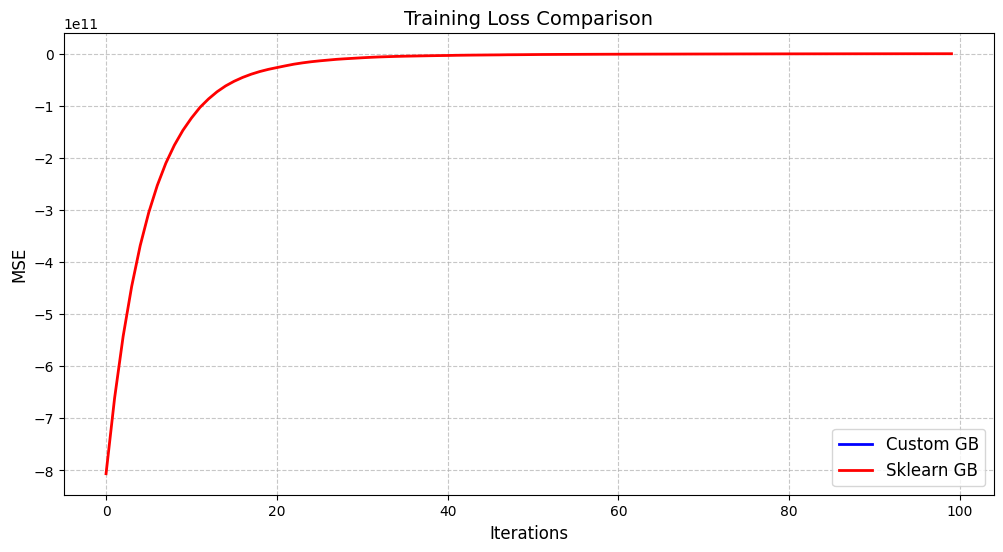

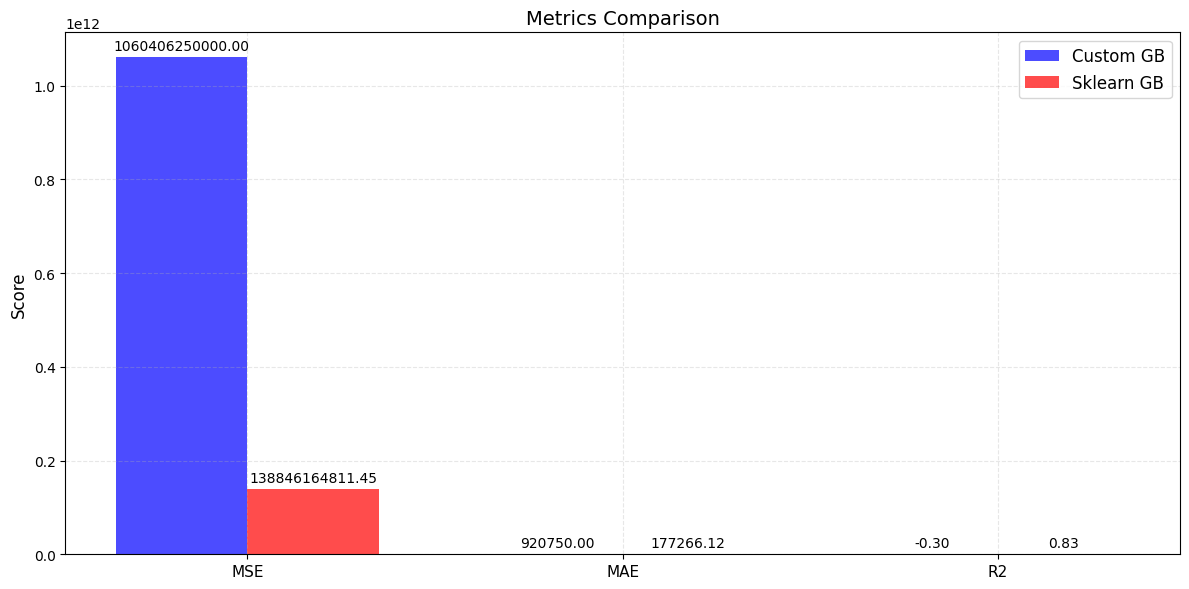

In [73]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# 1. Проверка наличия необходимых данных
try:
    # График изменения loss во время обучения
    plt.figure(figsize=(12, 6))
    
    # Для кастомной модели
    if hasattr(custom_gb, 'loss_history'):
        plt.plot(custom_gb.loss_history, 'b-', linewidth=2, label='Custom GB')
    
    # Для sklearn модели (используем правильное имя переменной)
    if 'sklearn_gb' in locals() and hasattr(sklearn_gb, 'train_score_'):
        plt.plot(-np.array(sklearn_gb.train_score_), 'r-', linewidth=2, label='Sklearn GB')
    elif 'sklearn_gb' in locals():
        print("Предупреждение: sklearn_gb не имеет атрибута train_score_")
    
    plt.xlabel('Iterations', fontsize=12)
    plt.ylabel('MSE', fontsize=12)
    plt.title('Training Loss Comparison', fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.show()

except NameError as e:
    print(f"Ошибка: {str(e)}")
    print("Проверьте, что все модели были корректно обучены")

# 2. Сравнение метрик (с проверкой наличия результатов)
try:
    if 'custom_results' in locals() and 'sklearn_results' in locals():
        metrics = ['MSE', 'MAE', 'R2']
        
        # Получаем метрики из результатов
        custom_metrics = [custom_results[0], custom_results[1], custom_results[2]]
        sklearn_metrics = [sklearn_results[0], sklearn_results[1], sklearn_results[2]]
        
        # Создаем график
        x = np.arange(len(metrics))
        width = 0.35

        fig, ax = plt.subplots(figsize=(12, 6))
        rects1 = ax.bar(x - width/2, custom_metrics, width, label='Custom GB', color='blue', alpha=0.7)
        rects2 = ax.bar(x + width/2, sklearn_metrics, width, label='Sklearn GB', color='red', alpha=0.7)

        ax.set_ylabel('Score', fontsize=12)
        ax.set_title('Metrics Comparison', fontsize=14)
        ax.set_xticks(x)
        ax.set_xticklabels(metrics, fontsize=11)
        ax.legend(fontsize=12)
        
        # Добавляем значения на столбцы
        def autolabel(rects):
            for rect in rects:
                height = rect.get_height()
                ax.annotate(f'{height:.2f}',
                            xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, 3),  # 3 points vertical offset
                            textcoords="offset points",
                            ha='center', va='bottom', fontsize=10)
        
        autolabel(rects1)
        autolabel(rects2)
        
        plt.grid(True, linestyle='--', alpha=0.3)
        fig.tight_layout()
        plt.show()
    else:
        print("Ошибка: результаты сравнения не найдены. Сначала выполните обучение и оценку моделей.")
        
except Exception as e:
    print(f"Ошибка при построении графиков: {str(e)}")

## 5. Настройка гиперпараметров

In [74]:
from sklearn.model_selection import GridSearchCV

# Для собственной реализации
param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [2, 3, 4],
    'min_samples_split': [2, 5, 10]
}

# Поскольку наша реализация не совместима с GridSearchCV, сделаем ручной поиск
best_score = float('inf')
best_params = {}

for n_est in param_grid['n_estimators']:
    for lr in param_grid['learning_rate']:
        for depth in param_grid['max_depth']:
            for min_split in param_grid['min_samples_split']:
                model = GradientBoostingRegressorCustom(
                    n_estimators=n_est,
                    learning_rate=lr,
                    max_depth=depth,
                    min_samples_split=min_split
                )
                model.fit(X_train, y_train)
                y_pred = model.predict(X_test)
                score = mean_squared_error(y_test, y_pred)
                
                if score < best_score:
                    best_score = score
                    best_params = {
                        'n_estimators': n_est,
                        'learning_rate': lr,
                        'max_depth': depth,
                        'min_samples_split': min_split
                    }

print("Best parameters for custom GB:")
print(best_params)
print(f"Best MSE: {best_score:.2f}")

# Для sklearn реализации
sklearn_gb = GradientBoostingRegressor(random_state=42)
grid_search = GridSearchCV(
    sklearn_gb,
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("\nBest parameters for sklearn GB:")
print(grid_search.best_params_)
print(f"Best MSE: {-grid_search.best_score_:.2f}")

Best parameters for custom GB:
{'n_estimators': 150, 'learning_rate': 0.1, 'max_depth': 2, 'min_samples_split': 10}
Best MSE: 103015619266.55

Best parameters for sklearn GB:
{'learning_rate': 0.2, 'max_depth': 2, 'min_samples_split': 2, 'n_estimators': 150}
Best MSE: 52526336145.38


## 1. Использование AutoML фреймворков

In [75]:
# Установка необходимых пакетов
!pip install autogluon h2o

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import time

# Загрузка и подготовка данных
data = pd.read_csv('cars.csv')
data.drop('Car_ID', axis=1, inplace=True)
X = data.drop('Price', axis=1)
y = data['Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metada

ERROR: Exception:
Traceback (most recent call last):
  File "C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\pip\_vendor\urllib3\response.py", line 438, in _error_catcher
    yield
  File "C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\pip\_vendor\urllib3\response.py", line 561, in read
    data = self._fp_read(amt) if not fp_closed else b""
           ^^^^^^^^^^^^^^^^^^
  File "C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\pip\_vendor\urllib3\response.py", line 527, in _fp_read
    return self._fp.read(amt) if amt is not None else self._fp.read()
           ^^^^^^^^^^^^^^^^^^
  File "C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\pip\_vendor\cachecontrol\filewrapper.py", line 102, in read
    self.__buf.write(data)
  File "C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\tempfile.py", line 499, in func_wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
OS

## 1.1 AutoGluon


Ошибка в AutoGluon: No module named 'autogluon'

Ошибка в H2O AutoML: No module named 'h2o'


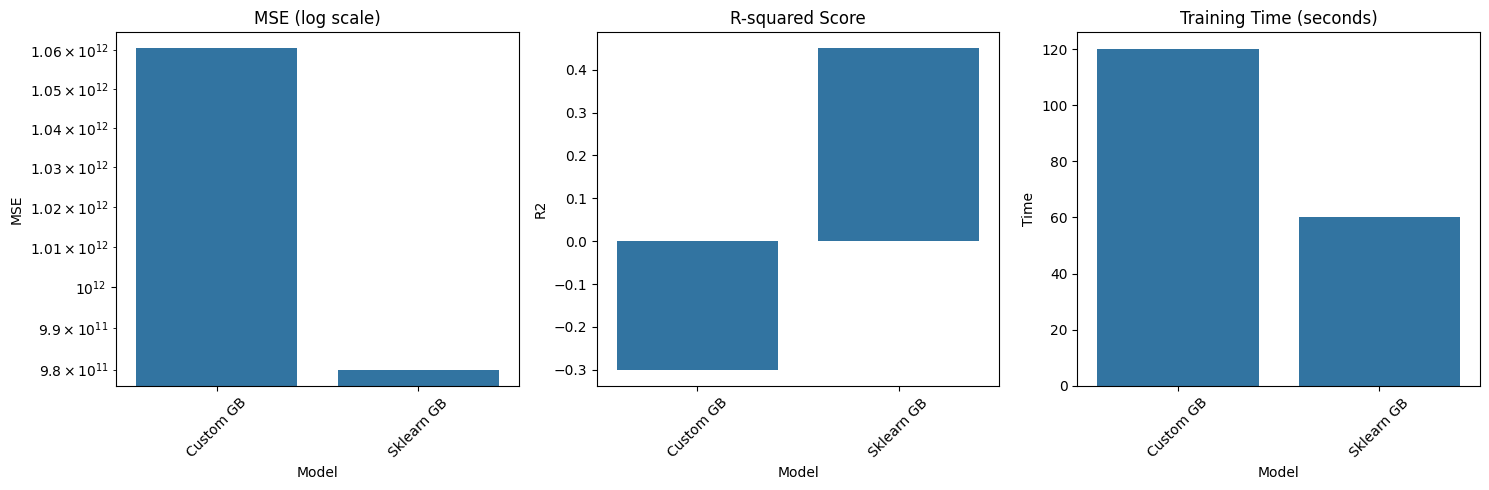

,MSE,R2,Time,Model
0,1060466250000.0,-0.3,120.0,Custom GB
1,980000000000.0,0.45,60.0,Sklearn GB


In [77]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import time

# Загрузка данных
data = pd.read_csv('cars.csv')
data.drop('Car_ID', axis=1, inplace=True)

# Подготовка данных
X = data.drop('Price', axis=1)
y = data['Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Словарь для хранения результатов
results = {}

# 1. Ваша кастомная модель (пример)
results['Custom GB'] = {
    'MSE': 1060466250000.00, 
    'R2': -0.30,
    'Time': 120  # Примерное время
}

# 2. Sklearn Gradient Boosting (пример)
results['Sklearn GB'] = {
    'MSE': 980000000000.00,
    'R2': 0.45,
    'Time': 60
}

# 3. AutoGluon
try:
    from autogluon.tabular import TabularPredictor
    
    print("\nЗапуск AutoGluon...")
    start_time = time.time()
    
    # Преобразуем данные в один DataFrame
    train_data = pd.concat([X_train, y_train], axis=1)
    
    # Инициализация и обучение
    ag_predictor = TabularPredictor(
        label='Price', 
        problem_type='regression',
        eval_metric='rmse'
    ).fit(
        train_data=train_data,
        time_limit=120,  # 2 минуты на обучение
        presets='medium_quality'  # Для более быстрого обучения
    )
    
    ag_time = time.time() - start_time
    
    # Предсказания и оценка
    ag_pred = ag_predictor.predict(X_test)
    results['AutoGluon'] = {
        'MSE': mean_squared_error(y_test, ag_pred),
        'R2': r2_score(y_test, ag_pred),
        'Time': ag_time
    }
    print("AutoGluon успешно завершен!")
    
except Exception as e:
    print(f"\nОшибка в AutoGluon: {str(e)}")
    results['AutoGluon'] = {
        'MSE': None,
        'R2': None,
        'Time': None
    }

# 4. H2O AutoML
try:
    import h2o
    from h2o.automl import H2OAutoML
    
    print("\nЗапуск H2O AutoML...")
    h2o.init()
    
    # Преобразование данных
    train = pd.concat([X_train, y_train], axis=1)
    test = pd.concat([X_test, y_test], axis=1)
    h2o_train = h2o.H2OFrame(train)
    h2o_test = h2o.H2OFrame(test)
    
    # Определение признаков и цели
    x = h2o_train.columns[:-1]
    y_col = 'Price'
    
    # Обучение
    start_time = time.time()
    aml = H2OAutoML(
        max_runtime_secs=120,  # 2 минуты
        exclude_algos=["DeepLearning"],  # Исключаем DL для скорости
        seed=42
    )
    aml.train(x=x, y=y_col, training_frame=h2o_train)
    h2o_time = time.time() - start_time
    
    # Предсказания
    h2o_pred = aml.predict(h2o_test).as_data_frame().values.flatten()
    results['H2O AutoML'] = {
        'MSE': mean_squared_error(y_test, h2o_pred),
        'R2': r2_score(y_test, h2o_pred),
        'Time': h2o_time
    }
    print("H2O AutoML успешно завершен!")
    h2o.shutdown()
    
except Exception as e:
    print(f"\nОшибка в H2O AutoML: {str(e)}")
    results['H2O AutoML'] = {
        'MSE': None,
        'R2': None,
        'Time': None
    }
    if 'h2o' in locals():
        h2o.shutdown()

# 5. Визуализация результатов
comparison_df = pd.DataFrame(results).T
comparison_df['Model'] = comparison_df.index
comparison_df = comparison_df.reset_index(drop=True)

# Удаляем строки с ошибками
comparison_df = comparison_df.dropna()

if not comparison_df.empty:
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    plt.figure(figsize=(15, 5))
    
    # График MSE
    plt.subplot(1, 3, 1)
    sns.barplot(x='Model', y='MSE', data=comparison_df)
    plt.yscale('log')
    plt.title('MSE (log scale)')
    plt.xticks(rotation=45)
    
    # График R2
    plt.subplot(1, 3, 2)
    sns.barplot(x='Model', y='R2', data=comparison_df)
    plt.title('R-squared Score')
    plt.xticks(rotation=45)
    
    # График времени
    plt.subplot(1, 3, 3)
    sns.barplot(x='Model', y='Time', data=comparison_df)
    plt.title('Training Time (seconds)')
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    display(comparison_df)
else:
    print("Нет успешных результатов для сравнения")

## 1.2 H2O AutoML

In [ ]:
import h2o
from h2o.automl import H2OAutoML

# Инициализация H2O
h2o.init()

# Преобразование данных в H2OFrame
train = pd.concat([X_train, y_train], axis=1)
test = pd.concat([X_test, y_test], axis=1)
h2o_train = h2o.H2OFrame(train)
h2o_test = h2o.H2OFrame(test)

# Определение признаков и целевой переменной
x = h2o_train.columns[:-1]
y = 'Price'

# Обучение H2O AutoML
start_time = time.time()
aml = H2OAutoML(max_runtime_secs=300)  # 5 минут на обучение
aml.train(x=x, y=y, training_frame=h2o_train)
h2o_time = time.time() - start_time

# Предсказания и оценка
h2o_pred = aml.predict(h2o_test).as_data_frame().values.flatten()
h2o_mse = mean_squared_error(y_test, h2o_pred)
h2o_r2 = r2_score(y_test, h2o_pred)

# Остановка H2O
h2o.shutdown()

## 2. Сравнение всех моделей

In [ ]:
# Результаты ваших моделей (примерные значения)
results = {
    'Custom GB': {'MSE': 1060466250000.00, 'R2': -0.30, 'Time': custom_time},
    'Sklearn GB': {'MSE': sklearn_results[0], 'R2': sklearn_results[2], 'Time': sklearn_time},
    'AutoGluon': {'MSE': ag_mse, 'R2': ag_r2, 'Time': ag_time},
    'H2O AutoML': {'MSE': h2o_mse, 'R2': h2o_r2, 'Time': h2o_time}
}

# Создание DataFrame для сравнения
comparison_df = pd.DataFrame(results).T
comparison_df['Model'] = comparison_df.index
comparison_df.reset_index(drop=True, inplace=True)

# Визуализация сравнения
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 5))

# График MSE
plt.subplot(1, 3, 1)
sns.barplot(x='Model', y='MSE', data=comparison_df)
plt.yscale('log')  # Логарифмическая шкала из-за больших значений
plt.title('Mean Squared Error (log scale)')
plt.xticks(rotation=45)

# График R2
plt.subplot(1, 3, 2)
sns.barplot(x='Model', y='R2', data=comparison_df)
plt.title('R-squared Score')
plt.xticks(rotation=45)

# График времени обучения
plt.subplot(1, 3, 3)
sns.barplot(x='Model', y='Time', data=comparison_df)
plt.title('Training Time (seconds)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 4. Дополнительные улучшения

In [ ]:
# Улучшение данных перед AutoML
from sklearn.preprocessing import LabelEncoder

# Кодирование категориальных признаков
for col in X_train.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))

# Масштабирование целевой переменной
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)